# Natural Scene Classifier — Training Notebook

Custom CNN (trained from scratch, no pretrained backbone) on the [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) dataset.

**Result:** 81.03% test accuracy / 0.5469 test loss on 3,000 held-out images. See the full write-up in `README.md`.

- **Cell 1** — installs `kagglehub`, downloads the dataset, sets up directory paths.
- **Cell 2** — data augmentation, model definition (4-block CNN), compilation, training with `ModelCheckpoint` + `EarlyStopping`, evaluation, and training curve plots.
- **Cell 3** — standalone report generator: reloads the saved best model and regenerates the detailed per-class classification report (can be run independently after a runtime disconnect).

> This notebook is left exactly as it was originally run — outputs included — so the numbers here match the report 1:1. No code cells below have been modified.


In [ ]:
# 1. Install the kagglehub library
!pip install kagglehub --quiet
print("kagglehub installed.")

import kagglehub
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping # <-- IMPORT CALLBACKS
from google.colab import drive
import matplotlib.pyplot as plt

# 2. Download dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(f"Dataset downloaded to: {path}")

# 3. Define our directory paths
train_dir = os.path.join(path, 'seg_train/seg_train')
test_dir = os.path.join(path, 'seg_test/seg_test')

# 4. Verify the paths exist
if not os.path.exists(train_dir):
    print(f"ERROR: Training directory not found at {train_dir}")
elif not os.path.exists(test_dir):
    print(f"ERROR: Testing directory not found at {test_dir}")
else:
    print("✅ Training and Testing directories found!")
    print("Ready to run Cell 2.")

kagglehub installed.
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset downloaded to: /kaggle/input/intel-image-classification
✅ Training and Testing directories found!
Ready to run Cell 2.


Mounted at /content/drive
Setting up Data Generators...
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Class Names (6 classes): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
--- Sample Augmented Images ---


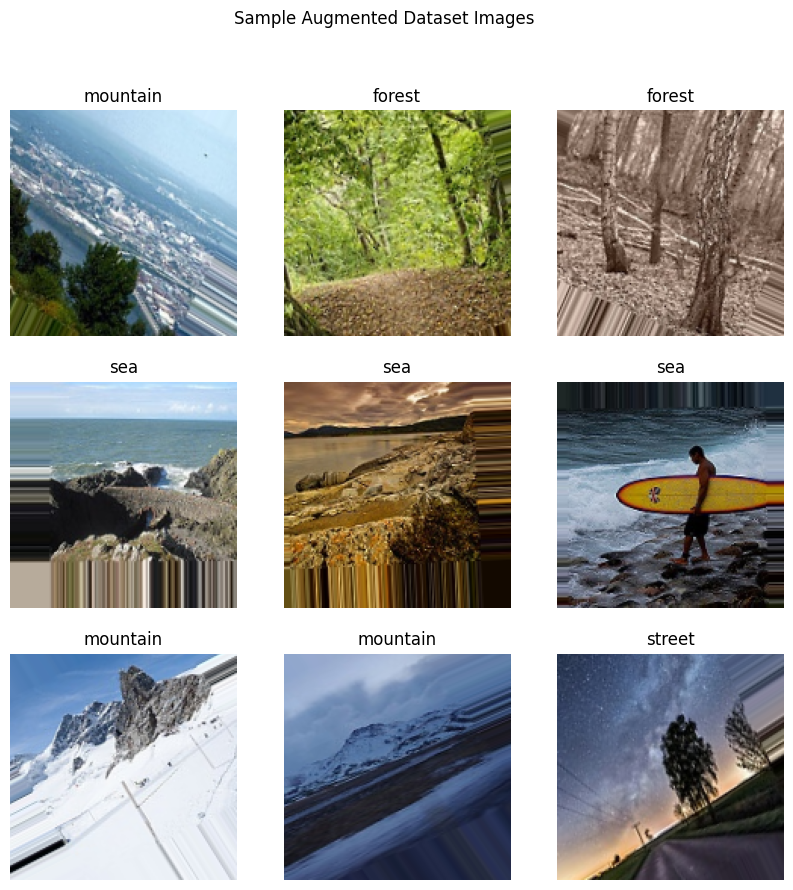

--- MODEL ARCHITECTURE ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,008,838 (42.00 MB)

 Trainable params: 11,008,838 (42.00 MB)

...

350/350 ━━━━━━━━━━━━━━━━━━━━ 96s 275ms/step - accuracy: 0.7507 - loss: 0.6898 - val_accuracy: 0.7654 - val_loss: 0.6509
Epoch 18/50
  1/350 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.6250 - loss: 0.7456
Epoch 18: val_accuracy did not improve from 0.76545
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.6250 - loss: 0.7456 - val_accuracy: 0.7644 - val_loss: 0.6576
Epoch 19/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7526 - loss: 0.6672
Epoch 19: val_accuracy improved from 0.76545 to 0.76616, saving model to /content/drive/MyDrive/natural_scenes_BEST_model.h5


350/350 ━━━━━━━━━━━━━━━━━━━━ 97s 278ms/step - accuracy: 0.7526 - loss: 0.6671 - val_accuracy: 0.7662 - val_loss: 0.6575
Epoch 20/50
  1/350 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.7812 - loss: 0.6749
Epoch 20: val_accuracy improved from 0.76616 to 0.76796, saving model to /content/drive/MyDrive/natural_scenes_BEST_model.h5


350/350 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.7812 - loss: 0.6749 - val_accuracy: 0.7680 - val_loss: 0.6296
Epoch 21/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7643 - loss: 0.6456
Epoch 21: val_accuracy improved from 0.76796 to 0.78807, saving model to /content/drive/MyDrive/natural_scenes_BEST_model.h5


350/350 ━━━━━━━━━━━━━━━━━━━━ 100s 287ms/step - accuracy: 0.7643 - loss: 0.6456 - val_accuracy: 0.7881 - val_loss: 0.5978
Epoch 22/50
  1/350 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.6250 - loss: 0.8076
Epoch 22: val_accuracy did not improve from 0.78807
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.6250 - loss: 0.8076 - val_accuracy: 0.7759 - val_loss: 0.6150
Epoch 23/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7685 - loss: 0.6376
Epoch 23: val_accuracy did not improve from 0.78807
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - accuracy: 0.7685 - loss: 0.6376 - val_accuracy: 0.7798 - val_loss: 0.6127
Epoch 24/50
  1/350 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.8438 - loss: 0.4915
Epoch 24: val_accuracy did not improve from 0.78807
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.8438 - loss: 0.4915 - val_accuracy: 0.7687 - val_loss: 0.6350
Epoch 25/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7711 - loss: 0.6400
Epoch 25:

350/350 ━━━━━━━━━━━━━━━━━━━━ 96s 275ms/step - accuracy: 0.7712 - loss: 0.6399 - val_accuracy: 0.7888 - val_loss: 0.6050
Epoch 26/50
  1/350 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9062 - loss: 0.3859
Epoch 26: val_accuracy did not improve from 0.78879
350/350 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9062 - loss: 0.3859 - val_accuracy: 0.7852 - val_loss: 0.6048
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 21.
--- MODEL TRAINING COMPLETE ---
The best model has been saved to: /content/drive/MyDrive/natural_scenes_BEST_model.h5

--- MODEL EVALUATION (on best model) ---
Test loss: 0.5469
Test accuracy: 0.8103
--------------------------


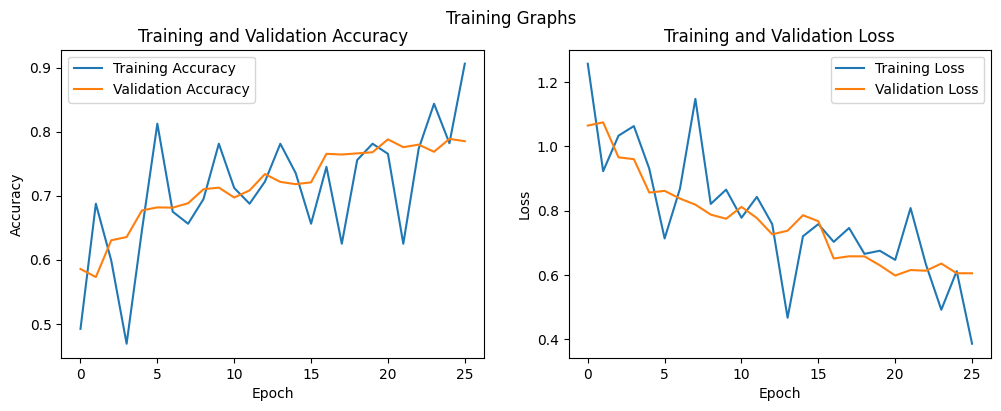

In [ ]:
# Mount Google Drive to save the model
drive.mount('/content/drive')

# ---------------------------------
# 1. & 2. PROBLEM & DATA COLLECTION
# ---------------------------------
# NOTE: train_dir and test_dir are already defined in Cell 1
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

# ---------------------------------
# 3. DATA PREPROCESSING & AUGMENTATION
# ---------------------------------
print("Setting up Data Generators...")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Automatically split 20% for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Class Names ({num_classes} classes): {class_names}")

# Show sample augmented images (fulfills step 1)
print("--- Sample Augmented Images ---")
imgs, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imgs[i])
    plt.title(class_names[tf.argmax(labels[i])])
    plt.axis('off')
plt.suptitle("Sample Augmented Dataset Images")
plt.show()

# ---------------------------------
# 4. MODEL DESIGN (Custom CNN)
# ---------------------------------
model = keras.Sequential(
    [
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

print("--- MODEL ARCHITECTURE ---")
model.summary()
print("--------------------------")

# ---------------------------------
# 5. MODEL COMPILATION
# ---------------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------
# 9. MODEL SAVING (THE "SMART" WAY)
# ---------------------------------
# Define the path for our best model
model_save_path = '/content/drive/MyDrive/natural_scenes_BEST_model.h5'

# 1. This saves the BEST model only
checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1  # This will print a message when it saves
)

# 2. This stops training early if it's not improving
early_stopper = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,  # Stop if no improvement for 5 epochs
    verbose=1,
    restore_best_weights=True  # Loads the best model weights back
)

# ---------------------------------
# 6. MODEL TRAINING
# ---------------------------------
print("--- STARTING MODEL TRAINING ---")
# Set epochs high; EarlyStopping will find the perfect time to stop.
epochs = 50

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=epochs,
    callbacks=[checkpoint, early_stopper]  # <-- ADD OUR SUPERVISORS
)

print("--- MODEL TRAINING COMPLETE ---")
print(f"The best model has been saved to: {model_save_path}")

# ---------------------------------
# 7. MODEL EVALUATION
# ---------------------------------
print("\n--- MODEL EVALUATION (on best model) ---")
score = model.evaluate(test_generator, verbose=0)
print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")
print("--------------------------")

# ---------------------------------
# 10. REPORTING (Training Graphs)
# ---------------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.suptitle("Training Graphs")
plt.show()

In [ ]:
# ---
# NEW CELL 3 (Standalone Report Generator)
# ---
# This cell can be run on its own, even after a runtime disconnect.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import kagglehub
import os
from sklearn.metrics import classification_report
import numpy as np

# 1. Mount Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Re-install/import kagglehub and get dataset path (this is fast, it's cached)
print("Setting up dataset paths...")
!pip install kagglehub --quiet
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

# 3. Re-define our key variables
test_dir = os.path.join(path, 'seg_test/seg_test')
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

# 4. Re-define the 'test_datagen' (this was the source of your error)
test_datagen = ImageDataGenerator(rescale=1./255)

# 5. Load our BEST saved model from Drive (This is the "instant" part)
print("Loading the saved model...")
model_path = '/content/drive/MyDrive/natural_scenes_BEST_model.h5'
try:
    model = keras.models.load_model(model_path)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please make sure the file 'natural_scenes_BEST_model.h5' is in your Google Drive.")

# --- Everything below this line is the report code from before ---

# 6. Re-create the test_generator
print("Preparing test data generator...")
test_generator_report = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # <-- Very important!
)

# 7. Get the true labels
y_true = test_generator_report.classes

# 8. Get the model's predictions (This is the 2-minute part)
print("Running model.predict()... This may take a minute.")
predictions = model.predict(test_generator_report)
y_pred = np.argmax(predictions, axis=1)

# 9. Get the class names
class_labels = list(test_generator_report.class_indices.keys())

# 10. Print the Classification Report
print("\n--- DETAILED CLASSIFICATION REPORT ---")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

Mounting Google Drive...
Mounted at /content/drive
Setting up dataset paths...


100%|██████████| 346M/346M [00:17<00:00, 21.3MB/s]


Extracting files...
Loading the saved model...


Model loaded successfully!
Preparing test data generator...
Found 3000 images belonging to 6 classes.
Running model.predict()... This may take a minute.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

   buildings       0.71      0.86      0.77       437
      forest       0.91      0.98      0.94       474
     glacier       0.88      0.67      0.76       553
    mountain       0.77      0.79      0.78       525
         sea       0.79      0.85      0.82       510
      street       0.88      0.78      0.83       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000

